##  Bank Customer Churn Prediction

In this project, I will develop a machine learning model to predict the probability of customers leaving a bank (churn prediction).

The main goal is to analyze customer data and identify patterns that indicate whether a client is likely to stop using the bank’s services. This type of analysis is extremely important for businesses, since retaining customers is often more cost-effective than acquiring new ones.

To achieve this, I will follow the CRISP-DM methodology (Cross Industry Standard Process for Data Mining), which structures the project into the following steps:

* **Business Understanding:** Define the problem and objectives of the analysis.
* **Data Understanding:** Explore the dataset and understand the main variables.
* **Data Preparation:** Clean and preprocess the data for modeling.
* **Modeling:** Train machine learning models to predict churn.
* **Evaluation:** Assess model performance using appropriate metrics.
* **Deployment:** Present insights or prepare the model for real-world use.

In this notebook, I will focus on the Exploratory Data Analysis (EDA), where I will explore the dataset, visualize patterns, and identify important relationships between variables.



## 1. Business Problem

Customer churn (service cancellation) represents one of the main challenges for banking institutions, as it directly impacts revenue and sustainable business growth. When a customer leaves the bank, the company not only loses the revenue that this customer would generate over time, but also needs to invest additional resources to acquire new customers.

In this context, many institutions face difficulties in proactively identifying which customers are likely to end their relationship with the bank. Without this predictive capability, retention actions tend to be reactive, inefficient, and more costly.

Therefore, the central problem of this project is: **how to identify customers with a higher probability of churn using historical data?**

Based on this analysis, it is possible to generate strategic insights and develop machine learning models capable of predicting customer behavior. This enables the bank to adopt preventive measures, such as personalized offers, service improvements, or loyalty programs, reducing churn rates and increasing customer retention.

Thus, this project aims not only to build a predictive model, but also to support data-driven decision-making, adding real value to the business.


## Project Benefits

* Identify customers with a high probability of churn in advance

* Enable proactive actions instead of reactive ones

* Optimize marketing and retention strategies

* Reduce costs by focusing on the most critical customers

* Increase customer retention

* Improve understanding of customer behavior

* Increase revenue and long-term profitability

* Strengthen customer relationships

* Generate a competitive advantage for the bank


##  Questions to be Answered

* What is the overall churn rate in the dataset?

* What is the correlation between numerical features and churn?

* Does age have an impact on customer churn?

* How does account balance influence the likelihood of churn?

* Are customers with more products less likely to churn?

* Do active members churn less than inactive members?

* Does having a credit card affect customer churn?

* Is there a difference in churn behavior across different countries?

* Are higher salary customers more or less likely to churn?

* What combination of features best explains customer churn?

* Which features are the most important for predicting churn?

* Are there specific customer profiles that are more likely to churn?

* Can we identify high-risk customers based on their characteristics?

* How can the bank reduce churn based on the identified patterns?


#### Importing the libraries

In [1]:
# Data manipulation and vizualization.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## 2 Understandin the data

* The dataset was collected from kaggle: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset


In [2]:
data_path = 'E:\data_science\Bank-Customer-Churn-Dataset\input\Bank Customer Churn Prediction.csv'
df = pd.read_csv(data_path)

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Usuario\AppData\Local\Temp\ipykernel_16640\3002518784.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  data_path = 'E:\data_science\Bank-Customer-Churn-Dataset\input\Bank Customer Churn Prediction.csv'


In [3]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


###  Data Dictionary

* **Customer_id:** Unique identifier for each customer

* **Credit_score:** Customer's credit score, indicating their creditworthiness

* **Country:** Country where the customer resides

* **Gender:** Customer's gender

* **Age:** Customer's age

* **Tenure:** Number of years the customer has been with the bank

* **Balance:** Account balance of the customer

* **Products_number:** Number of bank products the customer is using

* **Credit_card:** Indicates whether the customer has a credit card (1 = Yes, 0 = No)

* **Active_member:** Indicates whether the customer is an active member (1 = Yes, 0 = No)

* **Estimated_salary:** Estimated annual salary of the customer

* **Churn:** Indicates whether the customer left the bank (1 = Yes, 0 = No) 


Looking at dataset general information



In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [5]:
df.isnull().sum().sum()

np.int64(0)

Looking at some descriptive statistics

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
credit_score,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
products_number,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
credit_card,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
active_member,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
estimated_salary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48
churn,10000.0,2.037000e-01,0.402769,0.00,0.00,0.000000e+00,0.000000e+00,1.00


Some Insight:
1. Approximately 20% of customers have churned, indicating a significant churn rate that requires attention.

2. The customer base is mainly composed of middle-aged individuals, which may influence churn behavior and product preferences.

3. A significant portion of customers have a zero account balance, which may indicate low engagement or inactive accounts.

4. Most customers use a limited number of bank products, suggesting a low level of relationship with the bank.

5. Around 70% of customers have a credit card, making it a widely adopted product among clients.

6. Only about half of the customers are active members, which may be an important factor related to churn.

7. Customer salaries show a wide distribution, allowing for segmentation and deeper behavioral analysis.

8. Customers have, on average, a moderate tenure with the bank, which may influence their loyalty and likelihood of churning.


9. The combination of low balance and a small number of products may indicate low engagement, which can be associated with higher churn risk.



## 3. Split the data into train and test sets

* First of all, I will split the data into train and test sets

* Test set as supposed to be data the model as never seen before

* I will perform EDA focusing on the traning sat an order to avoid data leakage get a realistic representation and evalute the model correctly with new unseen data

* I  will specify statify=y so that the train_test_split function that the spitting process mantains the same percentage of each target class in both the traning and testing stes. This ins particulary useful when deaing with umbalanced datasets which is the case as there are more existing customers than attrited ones

In [7]:
# Features (X) e Target (y)
X = df.drop(['churn', 'customer_id'], axis=1)
y = df['churn']

# Split com stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% teste
    random_state=42,      # reprodutibilidade
    stratify=y            # mantém proporção do churn
)

print(f'Train predictor datasete shape: {X_train.shape}')
print(f'Train target datasete shape: {y_train.shape}')
print(f'Test predictor datasete shape: {X_test.shape}')
print(f'Test predictor datasete shape: {y_test.shape}')

Train predictor datasete shape: (8000, 10)
Train target datasete shape: (8000,)
Test predictor datasete shape: (2000, 10)
Test predictor datasete shape: (2000,)


In [8]:
print(f'Train target proportion: ')
print(f'{y_train.value_counts(normalize=True)}')
print(f'Test target proportion: ')
print(f'{y_test.value_counts(normalize=True)}')

Train target proportion: 
churn
0    0.79625
1    0.20375
Name: proportion, dtype: float64
Test target proportion: 
churn
0    0.7965
1    0.2035
Name: proportion, dtype: float64


## 4. Exploratory data analysis

I will explore the training set in order to gain a better understanding of how the features are distributed individually, as well as the relationships between them, including correlations, trends, and insights from the data, especially with regard to the target variable (churn).

To achieve this, I will perform univariate, bivariate, and multivariate analyses.

Additionally, I will use the entire training set (including both predictor and target variables) to take advantage of the Seaborn hue parameter for visualizations and to analyze the correlation matrix.

In [9]:
train = pd.concat([X_train, y_train], axis=1 )
train.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
2151,753,France,Male,57,7,0.00,1,1,0,159475.08,1
8392,739,Germany,Male,32,3,102128.27,1,1,0,63981.37,1
5006,755,Germany,Female,37,0,113865.23,2,1,1,117396.25,0
4117,561,France,Male,37,5,0.00,2,1,0,83093.25,0
7182,692,Germany,Male,49,6,110540.43,2,0,1,107472.99,0


I will create separate lists for categorical, numerical, and target features in order to analyze the data more effectively and perform appropriate analyses for each type of variable.

In [10]:
numerical_features = X_train.select_dtypes('number').columns.tolist()
categorical_features = X_train.select_dtypes('object').columns.tolist()

print(f'There are {len(numerical_features)} numerical features. They are:')
print(numerical_features)
print(f'There are {len(categorical_features)} catergorical features. They are:')
print(categorical_features)

There are 8 numerical features. They are:
['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']
There are 2 catergorical features. They are:
['country', 'gender']


C:\Users\Usuario\AppData\Local\Temp\ipykernel_16640\3021905528.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes('object').columns.tolist()


### Analysis of categorical variables

I will look at categorical feature unique values. Cardinality is an important factor when choosing an ecoding technique for them.

The analysis of categorical variables allows us to detect possible imbalances in the data, identifying whether any category appears more frequently than others. It also helps to understand the overall customer profile, showing how they are distributed across countries and gender. With this information, it is possible to prepare deeper analyses on churn, making it easier to identify patterns and factors that influence customer cancellation.

In [11]:
for feature in categorical_features:
    print(feature)
    print('.'*40)
    print(f'There are {train[feature].nunique()} unique values. They are: ')
    print(train[feature].value_counts(normalize=True))
    print()

country
........................................
There are 3 unique values. They are: 
country
France     0.499125
Germany    0.250625
Spain      0.250250
Name: proportion, dtype: float64

gender
........................................
There are 2 unique values. They are: 
gender
Male      0.548375
Female    0.451625
Name: proportion, dtype: float64



From this point on, I will start to visualize these distributions using graphs, making the analysis clearer and more intuitive.

### Target Destribuition

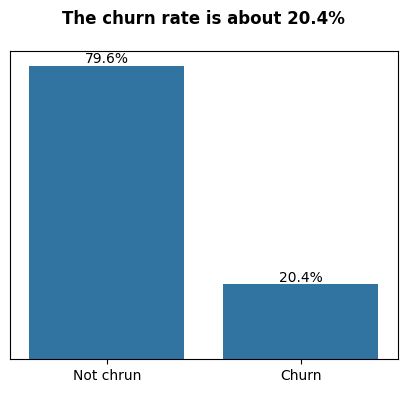

In [12]:
plt.figure(figsize= (5 ,4))
ax = sns.countplot(data= train, x= 'churn')
ax.set_title('The churn rate is about 20.4%', fontweight= 'bold', pad=20)
ax.set_xlabel('')
ax.set_xticks(range(2) , ['Not chrun', 'Churn'])
ax.yaxis.set_visible(False)

total = len(train)
counts = [count.get_height() for count in ax.patches]
percentages = [(count/total)*100 for count in counts]

for count, percentage in zip(ax.patches, percentages):
    x = count.get_x() + count.get_width() / 2
    y = count.get_height()
    ax.annotate(f'{percentage:.1f}%', (x,y), ha='center', va='bottom')

plt.show()

 

The target variable is imbalanced, with churners representing only 20.4% of the dataset. To address this, I will implement the following strategies:

Stratified Hold-out and K-Fold Cross-Validation: To maintain consistent target proportions across the test and validation sets, including during hyperparameter tuning.

Class Weighting: Assigning higher weights to the minority class so the model is penalized more heavily for misclassifying churners. These weights will be configured through the model's specific hyperparameters.

Precision-Recall Trade-off and Probability Scoring: Since the primary goal is to predict churn probabilities rather than simple binary outcomes, I will focus on probability estimates. This allows the bank to make more informed decisions by assessing how likely a client is to leave, rather than just if they will.

### Numerical features distribuitions

I will look at numerical features distribuitions below in order to see if there are skeawed distributions and which are the most common caluer for the bank's customers numeric attributes.

In [13]:
numplots_features = ['credit_score','age','tenure','balance','products_number','credit_card','active_member','estimated_salary']

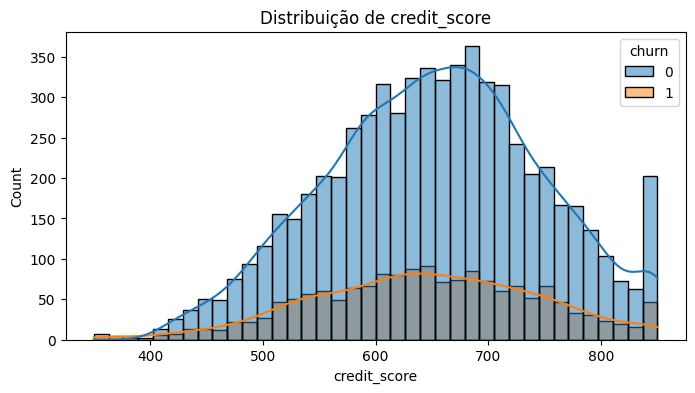

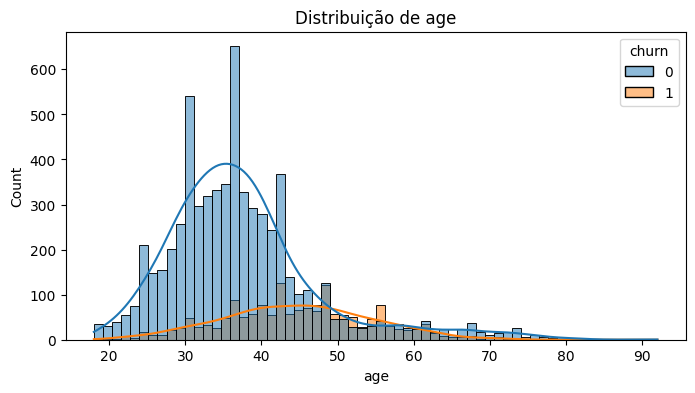

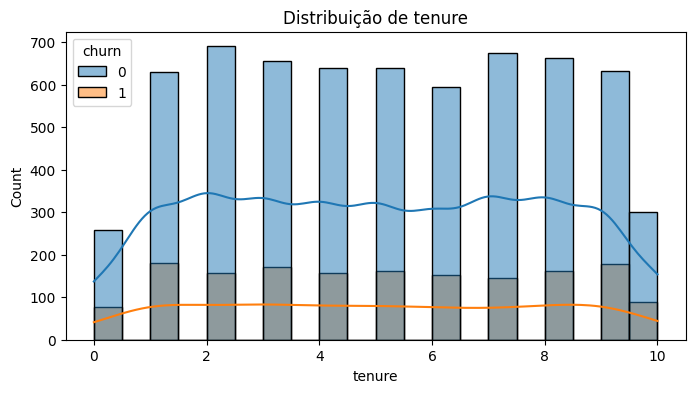

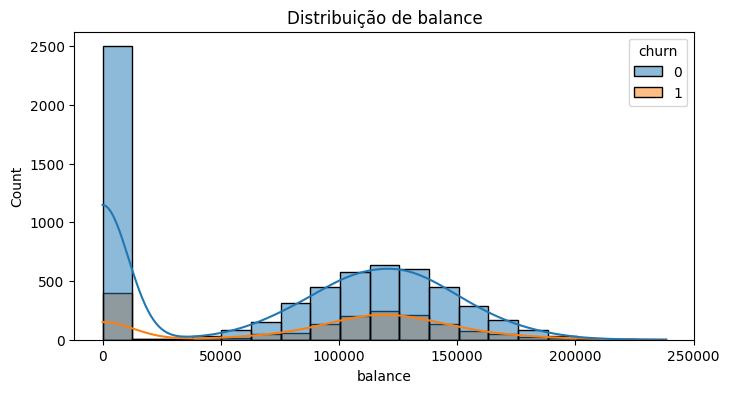

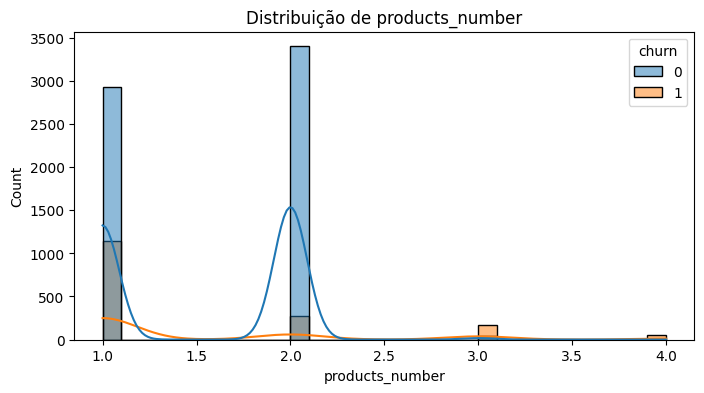

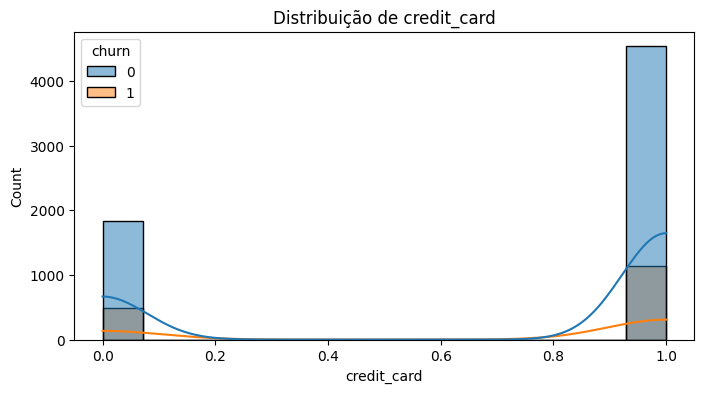

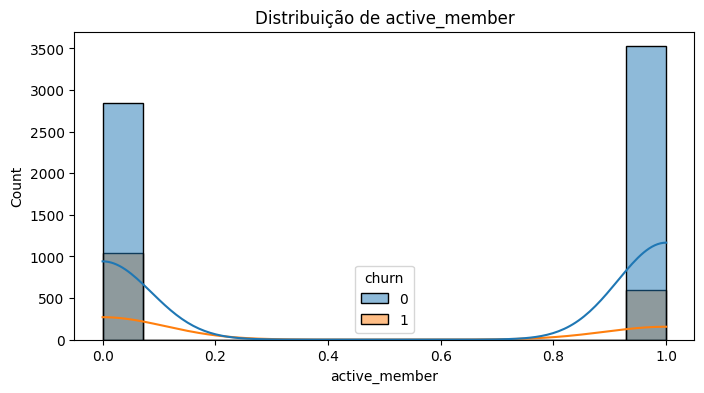

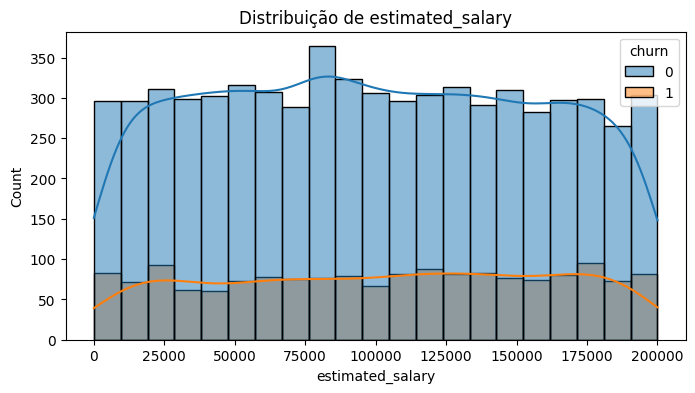

In [14]:
for col in numplots_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=train, x=col, hue= 'churn', kde=True)
    plt.title(f'Distribuição de {col}')
    plt.show()

1. Demographic and Financial Profile

Age: There is a clear and critical correlation between aging and churn. While the majority of the customer base is between 30 and 40 years old (and tends to stay), the attrition rate spikes for customers over 45.

High-Impact Insight: Older customers are leaving the bank at a significantly higher rate than younger ones. This suggests the bank might be failing to provide adequate retention products for middle-aged and senior segments, such as pension plans, low-risk investments, or tailored customer service.

Credit Score: Follows a well-defined normal distribution centered around 650. The spike at the maximum value (850) suggests a group of "prime" clients who should be prioritized for retention.

Estimated Salary: The distribution is uniform, meaning the bank has a similar number of clients across all income levels. Salary alone might not be a strong churn predictor.

2. Banking Behavior

Balance: There is a massive number of clients with zero balance (the first large spike). The rest follow a normal distribution centered around 125,000. Insight: Zero-balance clients are a high-risk segment or represent inactive accounts that skew the average.

Number of Products: Most clients use 1 or 2 products. Very few have 3 or 4. Insight: There is a cross-selling opportunity here. Usually, the more products a client holds, the lower the likelihood of churn.

Tenure: The distribution is almost flat between 1 and 9 years. This indicates that while the bank acquires customers, it doesn't necessarily see an increase in long-term loyalty over time.

3. Engagement

Credit Card and Active Member: While most clients have a credit card, the split between active and inactive members is nearly 50/50. Insight: Half of the customer base is "dormant." Engagement campaigns targeting inactive members are essential to prevent future attrition.

Detects outliers using the IQR method and returns indices, counts, and visualization with percentages.

In [15]:
def check_outliers(data, features):
    outlier_indexes = []
    outlier_counts = {}
    total_rows = len(data)
    

    n_features = len(features)
    nrows = (n_features // 2) + (n_features % 2)
    fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(15, nrows * 3.5))
    axes = axes.flatten()

    print(f"{'Campo':<20} | {'Qtd Outliers':<15} | {'Porcentagem':<10}")
    print("-" * 50)

    for i, col in enumerate(features):
       
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
      
        col_outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)].index
        outlier_indexes.extend(col_outliers)
        
        count = len(col_outliers)
        percentage = (count / total_rows) * 100
        outlier_counts[col] = count
        
       
        print(f"{col:<20} | {count:<15} | {percentage:>9.2f}%")
        
        
        sns.boxplot(x=data[col], ax=axes[i], color='#5dade2', fliersize=4)
        axes[i].set_title(f'{col}\n({count} outliers | {percentage:.2f}%)', fontsize=12)
        axes[i].set_xlabel('')

    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
    
    outlier_indexes = list(set(outlier_indexes))
    total_outliers = len(outlier_indexes)
    total_percentage = (total_outliers / total_rows) * 100
    
    print("-" * 50)
    print(f"TOTAL ACUMULADO: {total_outliers} linhas afetadas ({total_percentage:.2f}%)")
    
    return outlier_indexes, outlier_counts, total_outliers

Campo                | Qtd Outliers    | Porcentagem
--------------------------------------------------
credit_score         | 14              |      0.18%
age                  | 298             |      3.72%
tenure               | 0               |      0.00%
balance              | 0               |      0.00%
products_number      | 50              |      0.62%
credit_card          | 0               |      0.00%
active_member        | 0               |      0.00%
estimated_salary     | 0               |      0.00%


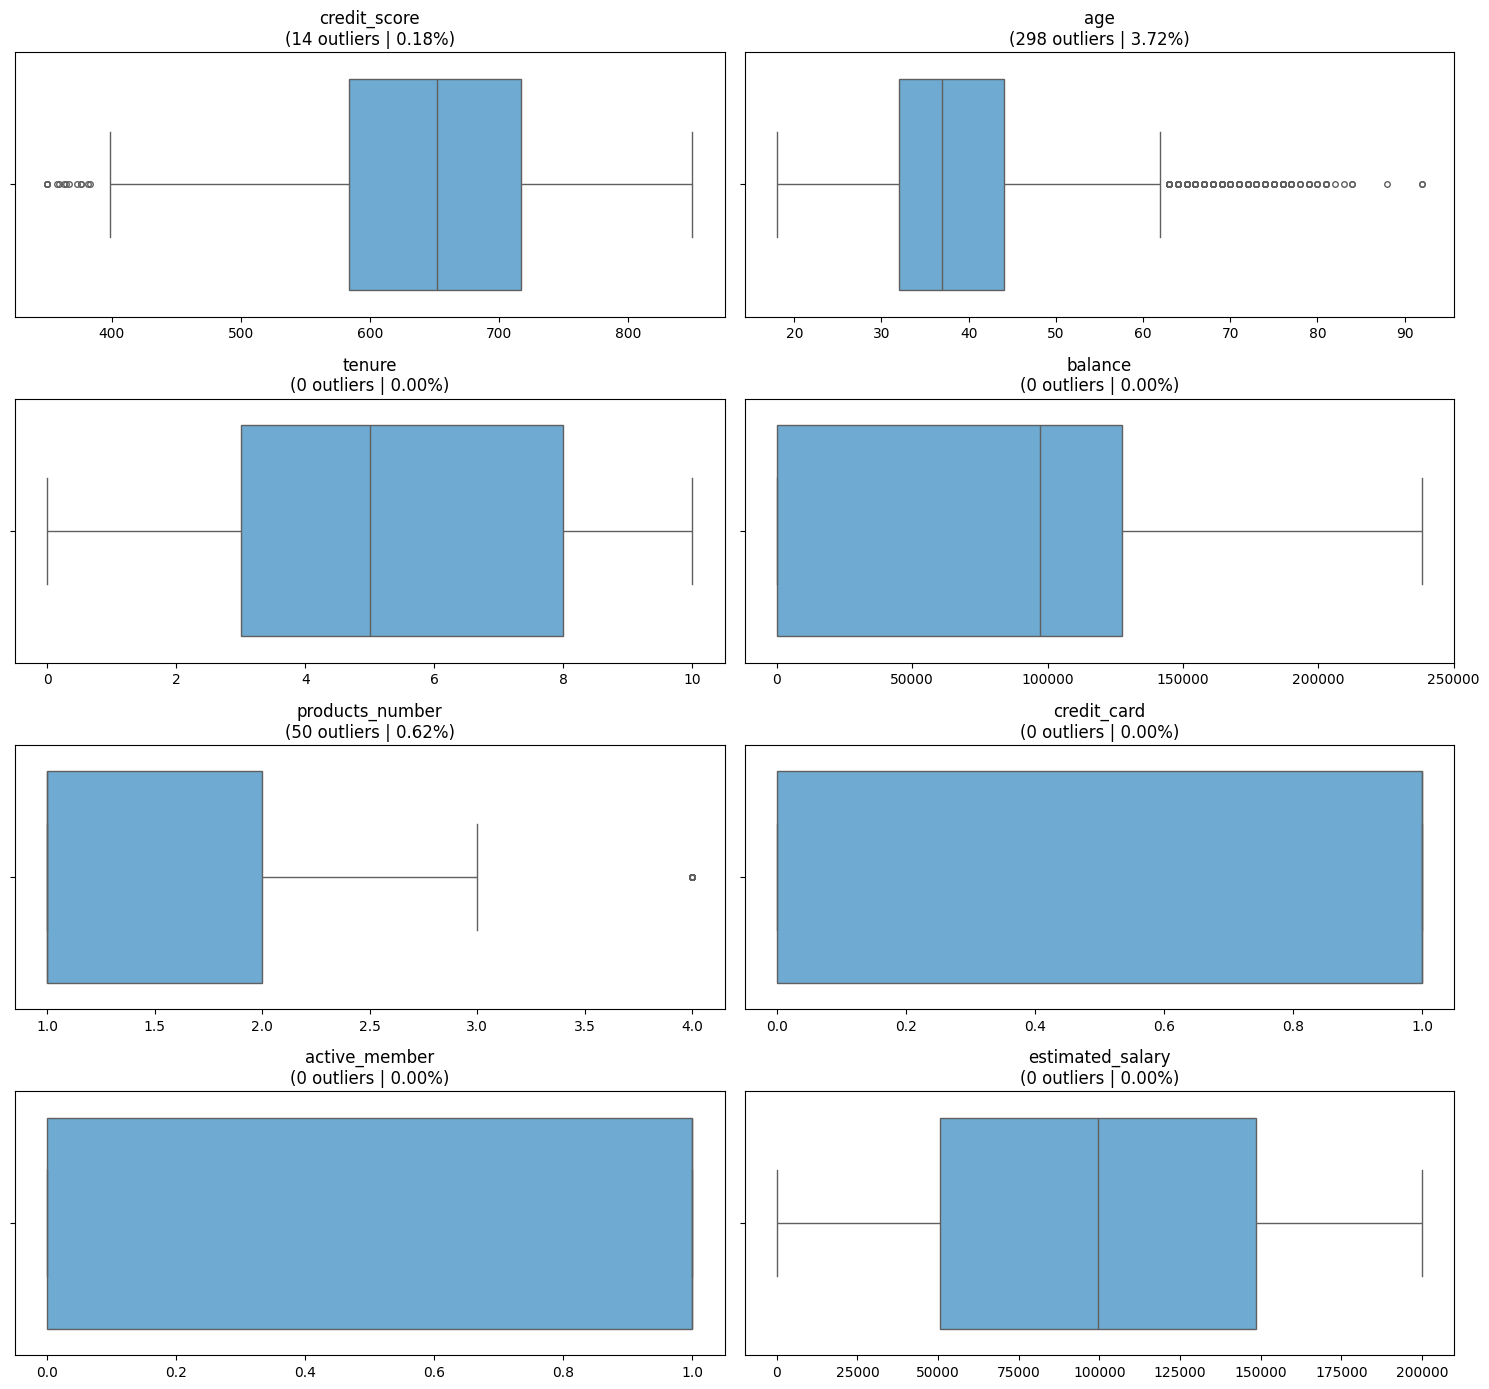

--------------------------------------------------
TOTAL ACUMULADO: 360 linhas afetadas (4.50%)


In [16]:
outlier_indexes, outlier_counts,  total_outliers = check_outliers(train, numplots_features)

Categorical features distribuitions

In [17]:
catplots_features = ['gender', 'country']



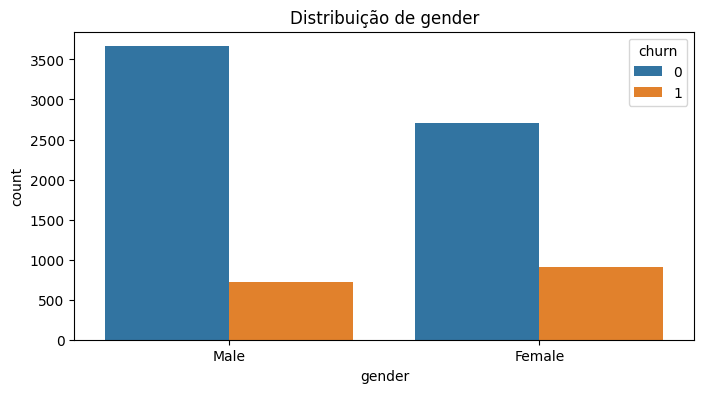

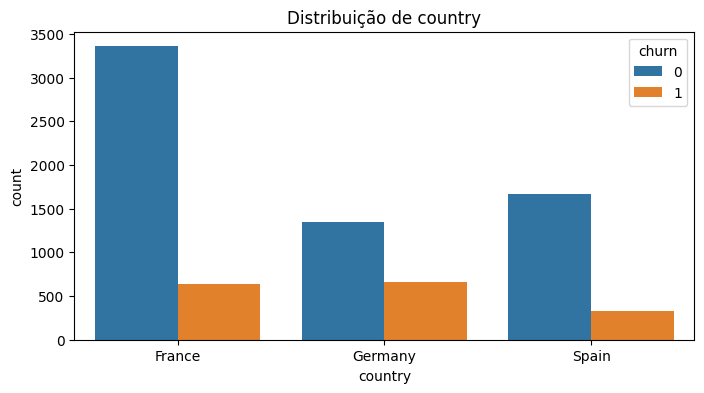

In [18]:
for col in catplots_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=train, x=col, hue='churn')
    plt.title(f'Distribuição de {col}')
    plt.show()

1. Gender
Distribution: There is a higher volume of male clients compared to female clients.

Insight: While the gender distribution is not perfectly balanced, it isn't skewed enough to require drastic sampling techniques. However, it is crucial to analyze this against the churn rate later; historically, gender can influence attrition due to different banking product preferences.

2. Country (Geography)
Market Concentration: France is the primary market, holding about 50% of the total customer base (approx. 4,000 clients).

Germany & Spain: The remaining 50% is split almost equally between Germany and Spain (approx. 2,000 each).

Strategic Insight: Your model is heavily biased toward French consumer behavior. If Germany or Spain shows a higher churn rate despite having fewer customers, the model needs to be sensitive enough to capture that regional risk without being "drowned out" by the French majority.

Geographic Churn Analysis:
Although Germany has the smallest customer base among the three countries, it exhibits the highest churn rate (approximately 50%). While France has the highest absolute volume of customers, their loyalty is significantly higher. This identifies Germany as a high-risk market, and the geographical feature will likely be a primary predictor in our machine learning model.

### Correlation Analysis

I will now examine the correlation matrix to identify linear relationships between features and the target variable. By using a Heatmap, I can pinpoint which variables (such as Age or Balance) have the strongest influence on Churn, as well as check for multicollinearity between predictors to ensure model stability.

In [19]:
corr_matrix = train.corr(numeric_only= True)

corr_matrix['churn'].sort_values(ascending=False)

churn               1.000000
age                 0.280378
balance             0.121441
estimated_salary    0.020260
tenure             -0.002368
credit_card        -0.014524
credit_score       -0.033998
products_number    -0.054462
active_member      -0.152286
Name: churn, dtype: float64

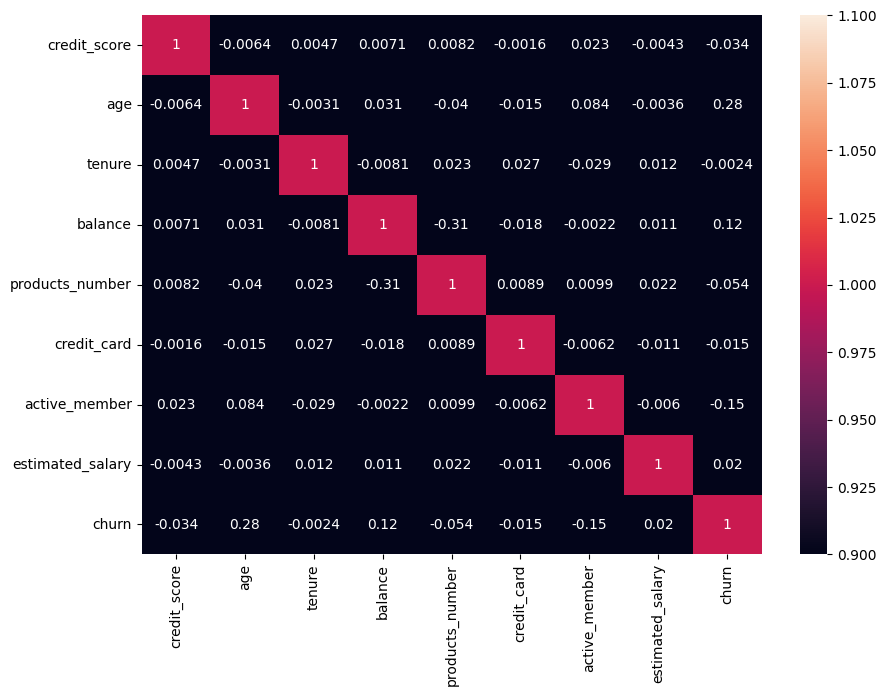

In [20]:
plt.figure(figsize=(10,7))
sns.heatmap(corr_matrix ,vmin=1, vmax= 1, annot=True)
plt.show()

Correlation Analysis and Insights 
1. The Main Driver: Age
The 0.28 Strength: Age shows the strongest positive correlation with churn (0.28) in the entire matrix.

Insight: This mathematically validates our previous observation: as age increases, the likelihood of churn also rises. Age is your most powerful predictor.

2. The Retention Anchor: Active Member
Negative Correlation (-0.15): The negative coefficient indicates an inverse relationship.

Insight: Being an active member effectively reduces churn. High engagement is currently the bank's best defense against customer attrition.

3. The Balance-Product Paradox
Correlation of -0.31: There is a notable negative link between balance and products_number.

Insight: High-balance customers tend to hold fewer products. This suggests that the bank is failing to cross-sell effectively to its wealthier clients, who might be keeping their main investments elsewhere.

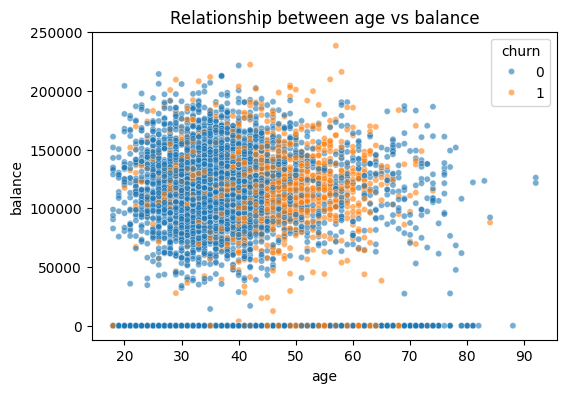

In [21]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=train, x='age', y='balance', hue='churn',alpha=0.6, s=20 )
plt.title('Relationship between age vs balance')
plt.show()

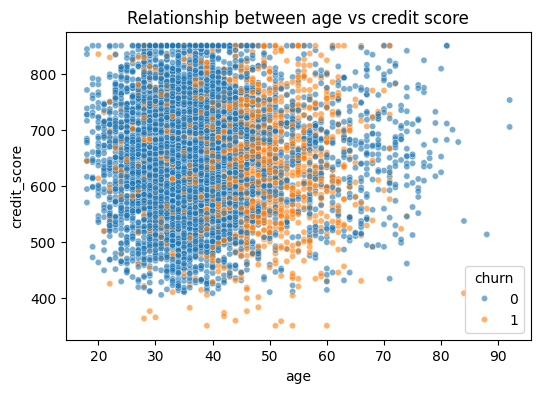

In [22]:
plt.figure(figsize = (6,4))
sns.scatterplot(data=train, x = 'age', y = 'credit_score', hue= 'churn',alpha=0.6, s=20)
plt.title('Relationship between age vs credit score')
plt.show()

Scatter Plot Analysis & Insights:
The visualization confirms that churn is not random. We identified a high-density churn zone among customers aged 45 to 65, particularly those with substantial balances (between 100k and 170k). This suggests that the bank is losing high-value, mature customers.

Conversely, Credit Score proved to be a weak predictor; churn is distributed almost uniformly across all score levels within the critical age bracket. This reinforces our finding that Age, rather than creditworthiness, is the primary driver of customer attrition in this dataset.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16640\1032185307.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='churn', y=col, ax=axes[i], palette='Set2')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_16640\1032185307.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='churn', y=col, ax=axes[i], palette='Set2')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_16640\1032185307.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='churn', y=col, ax=axes[i], palette='Set2')
C:\Users\Usuario\AppData\Loc

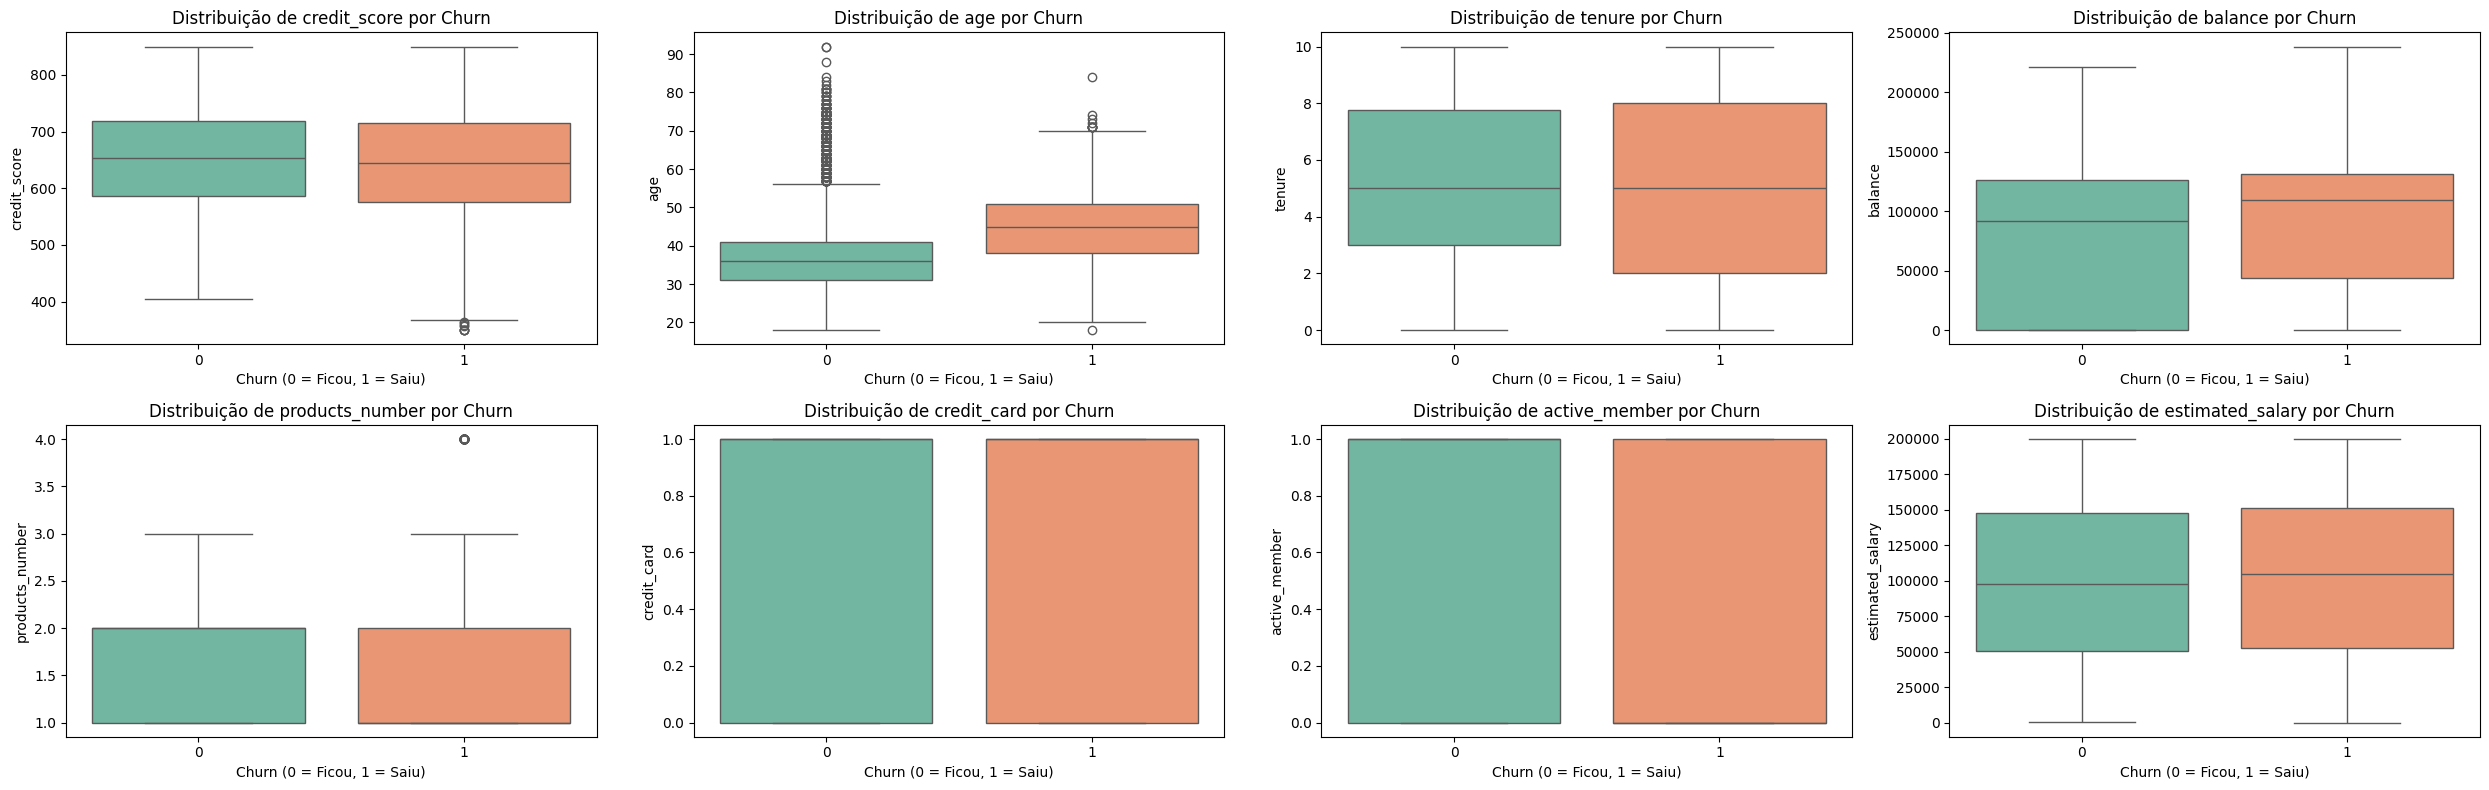

In [23]:
n_features = len(numplots_features)
ncols = 4
nrows = (n_features // ncols) + (n_features % ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(25, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numplots_features):
    sns.boxplot(data=train, x='churn', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribuição de {col} por Churn', fontsize=12)
    axes[i].set_xlabel('Churn (0 = Ficou, 1 = Saiu)')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1. Age as the Primary Churn Driver:
The boxplots provide undeniable evidence: the median age for retained customers (Churn 0) is around 35, whereas for those who churn (Churn 1), it jumps to approximately 45.

Insight: There is a clear generational gap. The bank is successful at retaining younger audiences (30-40), but struggles significantly with middle-aged clients. The risk of attrition spikes once a customer crosses the 40-year mark.

2. The High-Balance Trap:
The distribution for Churn 1 (orange box) is shifted upwards compared to Churn 0. Customers with lower balances (below 50k) are more likely to stay.

Insight: Churn is heavily concentrated among high-value customers with balances between 100k and 150k. This is a major red flag, as the bank is losing its most liquid and profitable clients.

3. Tenure and Early Attrition:
As observed, there is a specific churn pressure during the 2-to-3-year mark.

Insight: If a customer remains with the bank past the 3-year threshold, their loyalty tends to stabilize. Retention efforts should be prioritized during the initial "onboarding" phase and the first few years of the relationship.

## EDA conclusion

EDA Summary & Business Insights
Primary Driver: Age is the most critical factor. Customers over 45 show a much higher churn rate than the younger base.

Market Risk: Germany is a high-risk location, with nearly double the churn rate compared to other countries.

High-Value Attrition: Churn is concentrated among high-balance customers (100k - 150k), indicating that we are losing profitable accounts.

Retention Anchor: Active membership is the strongest predictor of loyalty, while Credit Score and Salary have minimal impact on the attrition decision.